In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/nba_player_stats_2026.csv")

In [ ]:
df.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,REB,AST,STL,BLK,TOV,PF,PTS,EFF,AST_TOV,STL_TOV
0,1629029,1,Luka Dončić,1610612747,LAL,64,2289,693,1457,0.476,...,495,530,105,34,255,153,2143,2146,2.08,0.41
1,1628983,2,Shai Gilgeous-Alexander,1610612760,OKC,68,2259,731,1321,0.553,...,292,448,95,52,151,139,2117,2189,2.97,0.63
2,1627759,3,Jaylen Brown,1610612738,BOS,71,2443,736,1543,0.477,...,492,364,72,27,259,191,2038,1817,1.41,0.28
3,201142,4,Kevin Durant,1610612745,HOU,78,2840,716,1376,0.520,...,426,372,62,71,246,142,2026,1992,1.51,0.25
4,1630178,5,Tyrese Maxey,1610612755,PHI,70,2661,694,1501,0.462,...,290,461,130,55,171,151,1980,1893,2.70,0.76


In [ ]:
df.columns

Index(['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM',
       'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
       'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'EFF',
       'AST_TOV', 'STL_TOV'],
      dtype='object')

In [ ]:
print(df.shape)

(582, 28)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 28 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   PLAYER_ID  582 non-null    int64  
 1   RANK       582 non-null    int64  
 2   PLAYER     582 non-null    object 
 3   TEAM_ID    582 non-null    int64  
 4   TEAM       582 non-null    object 
 5   GP         582 non-null    int64  
 6   MIN        582 non-null    int64  
 7   FGM        582 non-null    int64  
 8   FGA        582 non-null    int64  
 9   FG_PCT     582 non-null    float64
 10  FG3M       582 non-null    int64  
 11  FG3A       582 non-null    int64  
 12  FG3_PCT    582 non-null    float64
 13  FTM        582 non-null    int64  
 14  FTA        582 non-null    int64  
 15  FT_PCT     582 non-null    float64
 16  OREB       582 non-null    int64  
 17  DREB       582 non-null    int64  
 18  REB        582 non-null    int64  
 19  AST        582 non-null    int64  
 20  STL       

In [ ]:
# Per Game Stats
df['PPG'] = df['PTS']/df['GP']
df['RPG'] = df['REB']/df['GP']
df['APG'] = df['AST']/df['GP']
df['SPG'] = df['STL']/df['GP']
df['BPG'] = df['BLK']/df['GP']
df['TOVPG'] = df['TOV']/df['GP']

# Efficiency Metrics
df['FG_PCT'] = df['FG_PCT'] * 100
df['TS_PCT'] = df['PTS'] / (2 * (df['FGA'] + 0.44 * df['FTA'])) * 100

# Advanced Usage
df['Usage_Rate'] = (df['FGA'] + 0.44 * df['FTA'] + df['TOV']) / df['MIN'] * 100

# Filter players with minimum games
df_mvp = df[df['GP'] >= 50].copy()

print("Shape after filtering:", df_mvp.shape)
print("\nTop 10 PPG leaders:")
print(df_mvp.nlargest(10, 'RPG')[['PLAYER', 'TEAM', 'PPG', 'APG']])

print("\nNew Features Added Successfully!")

Shape after filtering: (304, 36)

Top 10 PPG leaders:
                 PLAYER TEAM        PPG        APG
9          Nikola Jokić  DEN  27.676923  10.723077
22   Karl-Anthony Towns  NYK  20.053333   3.013333
93      Donovan Clingan  POR  12.129870   2.103896
18    Victor Wembanyama  SAS  25.000000   3.109375
121         Rudy Gobert  MIN  10.907895   1.684211
34          Jalen Duren  DET  19.500000   1.971429
17        Jalen Johnson  ATL  22.513889   7.861111
26          Bam Adebayo  MIA  20.109589   3.178082
53          Evan Mobley  CLE  18.153846   3.600000
115         Kel'el Ware  MIA  11.051948   0.727273

New Features Added Successfully!


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split


In [ ]:
features = ['PPG', 'RPG','APG', 'SPG', 'BPG', 'FG_PCT', 'TS_PCT', 'Usage_Rate', 'GP', 'MIN', 'EFF']

In [ ]:
X = df_mvp[features]
y = df_mvp['EFF']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# model
model = XGBRegressor(
    n_estimator=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:04:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=300,
             n_estimators=None, n_jobs=None, ...)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Results
from sklearn.metrics import mean_absolute_error, r2_score
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 4))

# Top 10 Predicted MVP Candidates
df_mvp['Predicted_MVP_Score'] = model.predict(X)
print("\nTop 10 Predicted MVP Candidates:")
print(df_mvp.nlargest(10, 'Predicted_MVP_Score')[['PLAYER', 'TEAM', 'PPG', 'RPG', 'APG', 'Predicted_MVP_Score']])

MAE: 18.33
R2 Score: 0.9749

Top 10 Predicted MVP Candidates:
                     PLAYER TEAM        PPG        RPG        APG  \
1   Shai Gilgeous-Alexander  OKC  31.132353   4.294118   6.588235   
0               Luka Dončić  LAL  33.484375   7.734375   8.281250   
9              Nikola Jokić  DEN  27.676923  12.861538  10.723077   
18        Victor Wembanyama  SAS  25.000000  11.500000   3.109375   
17            Jalen Johnson  ATL  22.513889  10.277778   7.861111   
3              Kevin Durant  HOU  25.974359   5.461538   4.769231   
22       Karl-Anthony Towns  NYK  20.053333  11.853333   3.013333   
28           Scottie Barnes  TOR  18.100000   7.500000   5.925000   
7              Jamal Murray  DEN  25.400000   4.400000   7.133333   
4              Tyrese Maxey  PHI  28.285714   4.142857   6.585714   

    Predicted_MVP_Score  
1           2183.814453  
0           2144.643066  
9           2064.232422  
18          2037.092773  
17          2028.321777  
3           1991.61010

**Top 10 MVP Candidate Bar Chart**

/tmp/ipykernel_7646/529864079.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Predicted_MVP_Score', y='PLAYER', data=top10, palette='viridis')


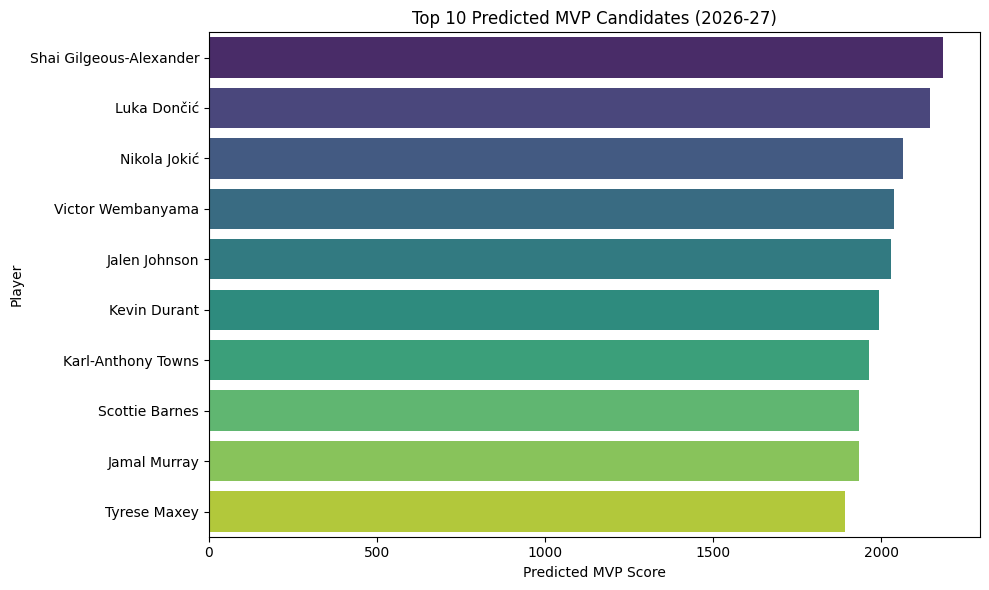

In [ ]:
top10 = df_mvp.nlargest(10, 'Predicted_MVP_Score')

plt.figure(figsize=(10,6))
sns.barplot(x='Predicted_MVP_Score', y='PLAYER', data=top10, palette='viridis')
plt.title('Top 10 Predicted MVP Candidates (2026-27)')
plt.xlabel('Predicted MVP Score')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

**Player Stats Comparasion**

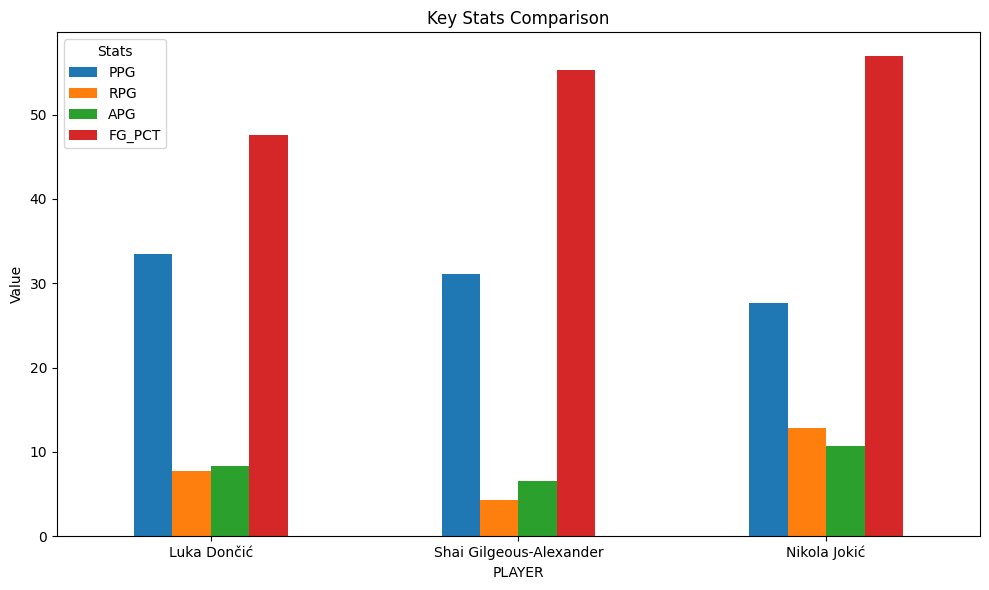

In [ ]:
players = ['Luka Dončić', 'Shai Gilgeous-Alexander', 'Nikola Jokić']

comparison = df_mvp[df_mvp['PLAYER'].isin(players)][['PLAYER', 'PPG', 'RPG', 'APG', 'FG_PCT']]

comparison.plot(x='PLAYER', kind='bar', figsize=(10,6))
plt.title('Key Stats Comparison')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.legend(title='Stats')
plt.tight_layout()
plt.show()

**Feature Importance Plot**

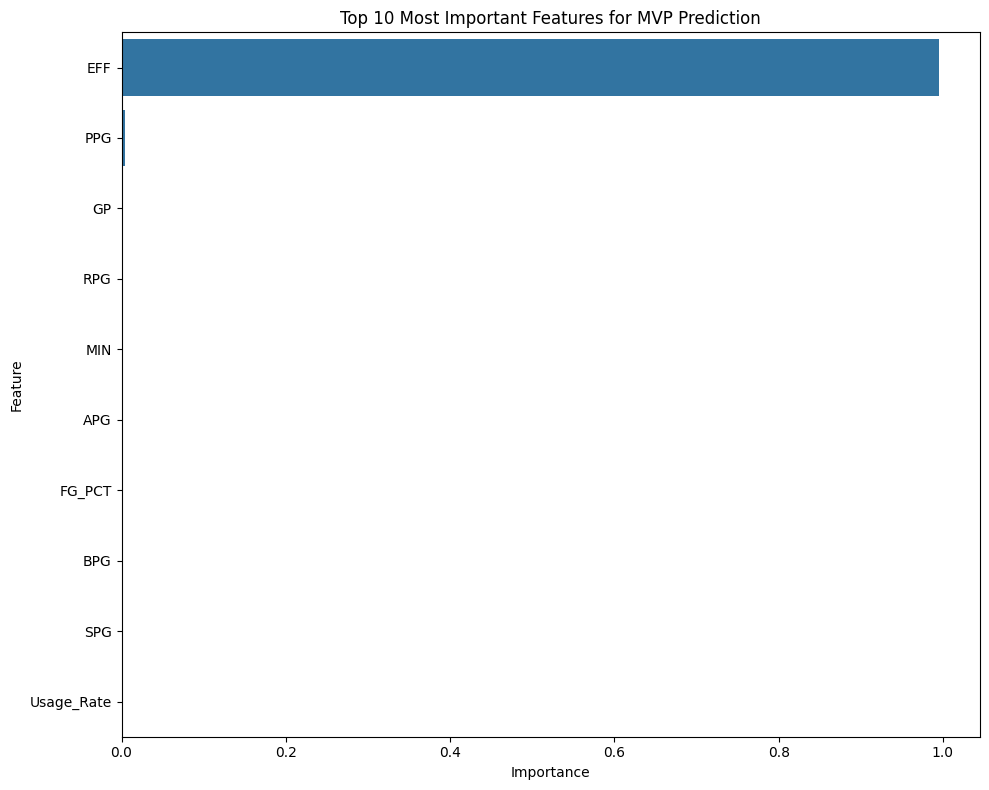

In [ ]:
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title('Top 10 Most Important Features for MVP Prediction')
plt.tight_layout()
plt.show()

**Changing Target Features**

In [ ]:
# Better target: Weighted Efficiency + playing time
df_mvp['MVP_Score'] = (df_mvp['EFF'] * df_mvp['GP'] * 0.6) + (df_mvp['PPG'] * 10)

In [ ]:
# Retrain Model
X = df_mvp[features]
y = df_mvp['MVP_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Model
model = XGBRegressor(n_estimators=300, max_deepth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:45:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "max_deepth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_deepth=6, max_delta_step=None,
             max_depth=None, max_leaves=None, min_child_weight=None,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=300, n_jobs=None, ...)

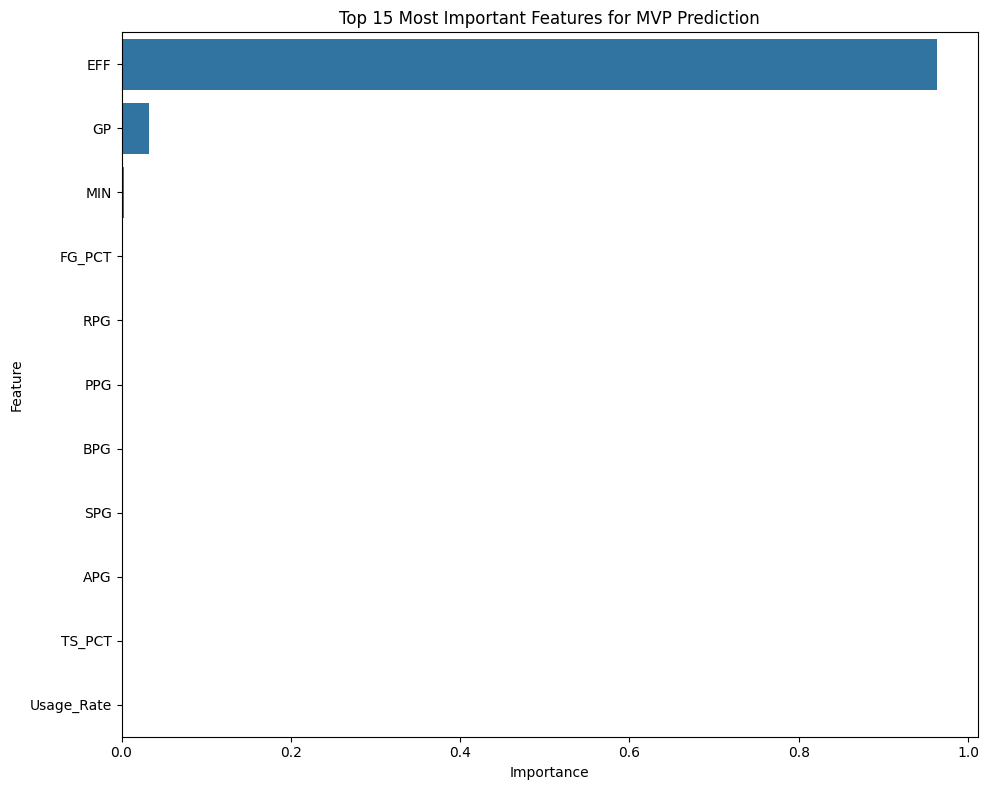

   Feature  Importance
10     EFF    0.963108
8       GP    0.032437
9      MIN    0.002937
5   FG_PCT    0.000428
1      RPG    0.000259
0      PPG    0.000244
4      BPG    0.000212
3      SPG    0.000155
2      APG    0.000111
6   TS_PCT    0.000055


In [ ]:
# Feature Importance (new)
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)


plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Most Important Features for MVP Prediction')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

In [ ]:
# Better MVP Score (balanced)
df_mvp['MVP_Score'] = (
    df_mvp['PPG'] * 0.4 +
    df_mvp['RPG'] * 0.15 +
    df_mvp['APG'] * 0.15 +
    df_mvp['EFF'] * 0.2 +
    df_mvp['GP'] * 0.1
    )

In [ ]:
# Retrain model with new features
X = df_mvp[features]
y = df_mvp['MVP_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBRegressor(n_estimator=300, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:59:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=300,
             n_estimators=None, n_jobs=None, ...)

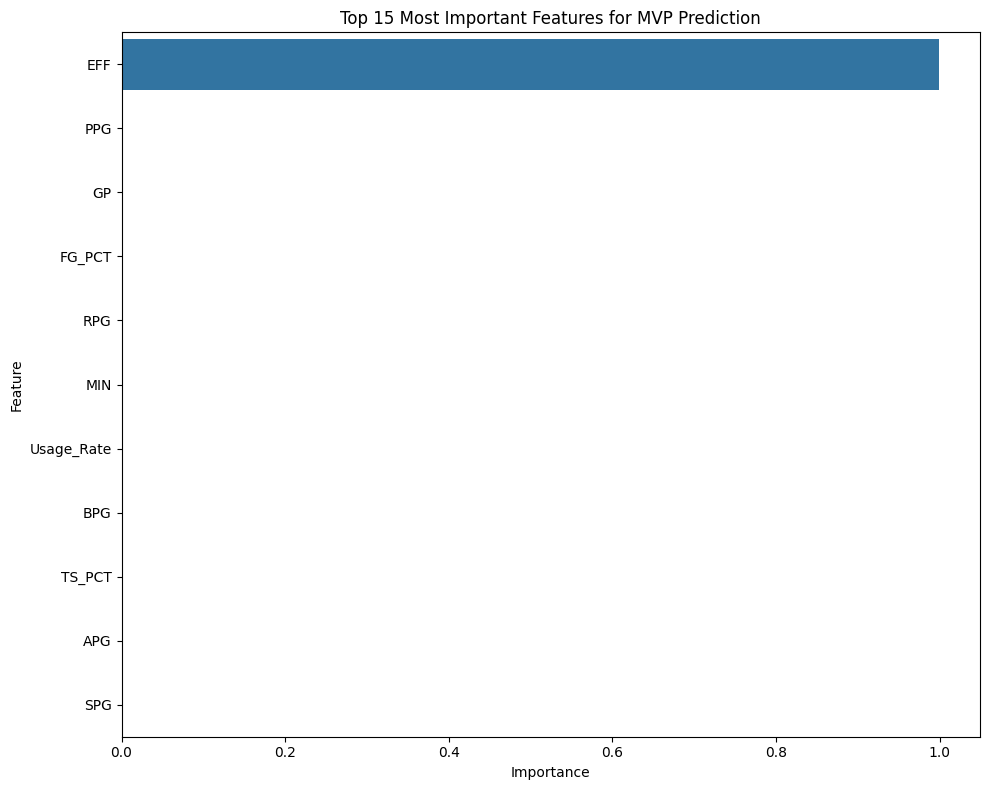

       Feature  Importance
10         EFF    0.999260
0          PPG    0.000300
8           GP    0.000275
5       FG_PCT    0.000048
1          RPG    0.000033
9          MIN    0.000025
7   Usage_Rate    0.000023
4          BPG    0.000011
6       TS_PCT    0.000010
2          APG    0.000008


In [ ]:
# New Feature Importance
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Most Important Features for MVP Prediction')
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

In [ ]:
# Removing EFF Feature
features = ['PPG', 'RPG', 'APG', 'SPG', 'BPG', 'FG_PCT', 'TS_PCT', 'Usage_Rate', 'GP', 'MIN']

X = df_mvp[features]
y = df_mvp['MVP_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = XGBRegressor(n_estimator=300, max_depth=6, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:11:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimator=300,
             n_estimators=None, n_jobs=None, ...)

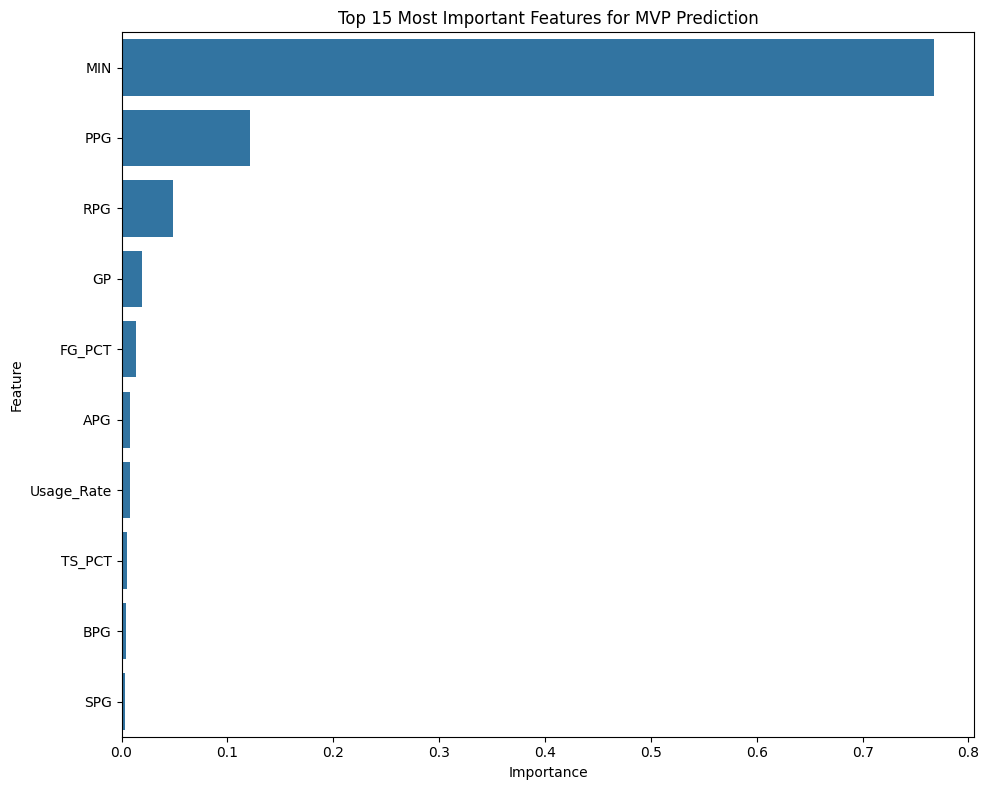

      Feature  Importance
9         MIN    0.767222
0         PPG    0.121606
1         RPG    0.048228
8          GP    0.019680
5      FG_PCT    0.013258
2         APG    0.008146
7  Usage_Rate    0.008115
6      TS_PCT    0.005501
4         BPG    0.004660
3         SPG    0.003583


In [ ]:
# New Feature Importance
importances = model.feature_importances_
feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
plt.title('Top 15 Most Important Features for MVP Prediction')
plt.tight_layout()
plt.show()

print(feat_imp.head(20))

In [ ]:
# Predictions
df_mvp['Predicted_MVP_Score'] = model.predict(X)

print("=== Final Top 10 MVP Candidates (2026-27) ===\n")
print(df_mvp.nlargest(10, 'Predicted_MVP_Score')[['PLAYER', 'TEAM', 'PPG', 'RPG', 'APG', 'MIN', 'Predicted_MVP_Score']])

# Model Performance
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = model.predict(X_test)
print("\nR2 Score:", round(r2_score(y_test, y_pred), 4))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))

=== Final Top 10 MVP Candidates (2026-27) ===

                     PLAYER TEAM        PPG        RPG        APG   MIN  \
1   Shai Gilgeous-Alexander  OKC  31.132353   4.294118   6.588235  2259   
0               Luka Dončić  LAL  33.484375   7.734375   8.281250  2289   
18        Victor Wembanyama  SAS  25.000000  11.500000   3.109375  1866   
3              Kevin Durant  HOU  25.974359   5.461538   4.769231  2840   
9              Nikola Jokić  DEN  27.676923  12.861538  10.723077  2265   
22       Karl-Anthony Towns  NYK  20.053333  11.853333   3.013333  2322   
28           Scottie Barnes  TOR  18.100000   7.500000   5.925000  2681   
4              Tyrese Maxey  PHI  28.285714   4.142857   6.585714  2661   
30            Amen Thompson  HOU  18.265823   7.772152   5.316456  2953   
7              Jamal Murray  DEN  25.400000   4.400000   7.133333  2652   

    Predicted_MVP_Score  
1            457.640564  
0            451.221130  
18           425.961700  
3            418.117249